In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from operation_cases import InclusionOfComponent, simulate_energy_system, UncontrollableSignalsSource, Controller

In [3]:
simulation_time = 12 * 60 * 60 # 12 hours
dynamical_model_time_step = 5
simulation_steps_number = simulation_time // dynamical_model_time_step

In [4]:
P_RS = 0
P_LD = 5000
P_FC = 0
P_EZ = 0
SOC_BS = 50
S_MG_imp = InclusionOfComponent.ON
S_FC = InclusionOfComponent.OFF
S_EZ = InclusionOfComponent.OFF
S_BS = InclusionOfComponent.ON

In [5]:
[P_RS_data,
 P_LD_data,
 P_MG_data,
 P_FC_data,
 P_EZ_data,
 P_BS_data,
 SOC_BS_data,
 operation_mode_data] = simulate_energy_system(simulation_steps_number,
                                               dynamical_model_time_step,
                                               initial_state = [P_RS,
                                                                P_LD,
                                                                P_FC,
                                                                P_EZ,
                                                                SOC_BS,
                                                                S_MG_imp,
                                                                S_FC,
                                                                S_EZ,
                                                                S_BS],
                                               disturbance_signal_source = UncontrollableSignalsSource(dynamical_model_time_step),
                                               control_signal_source = Controller(dynamical_model_time_step))

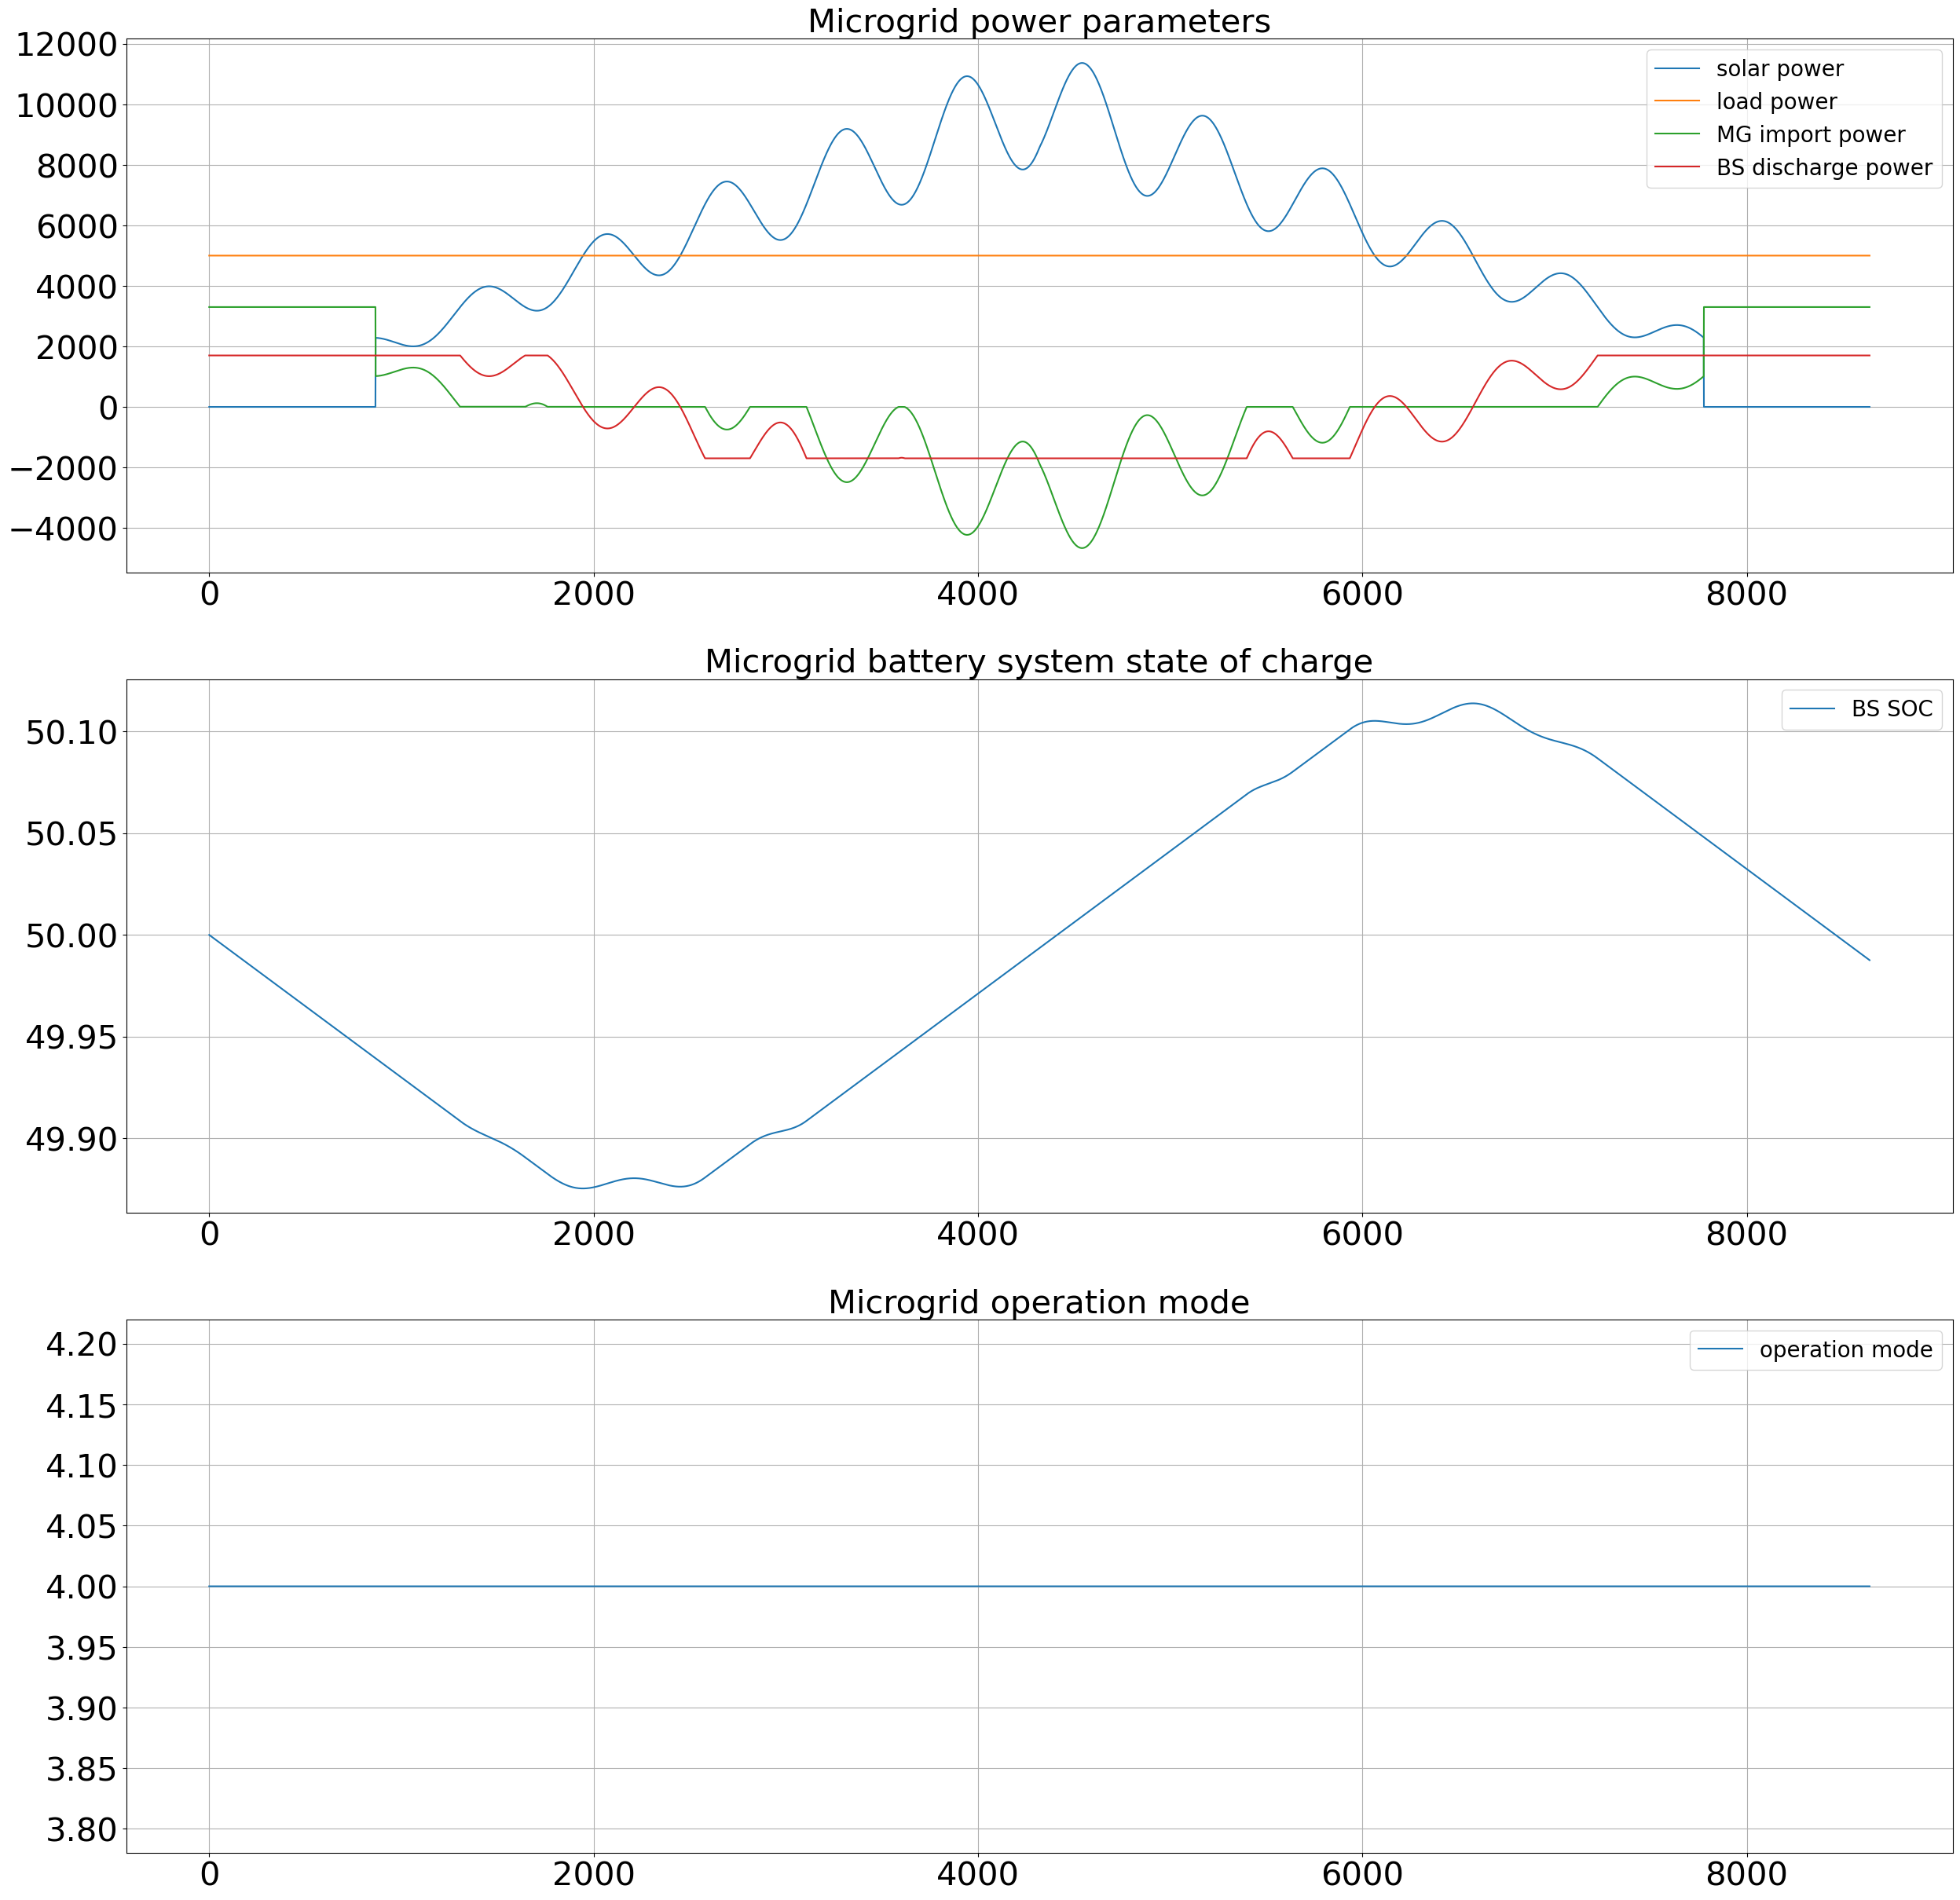

In [6]:
plt.figure(figsize=(30, 30))

plt.subplot(311)
plt.title("Microgrid power parameters", fontsize=30)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.plot(P_RS_data, label = "solar power")
plt.plot(P_LD_data, label = "load power")
plt.plot(P_MG_data, label = "MG import power")
plt.plot(P_BS_data, label = "BS discharge power")
plt.legend(prop={'size': 20})
plt.grid(visible=True)

plt.subplot(312)
plt.title("Microgrid battery system state of charge", fontsize=30)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.plot(SOC_BS_data, label = "BS SOC")
plt.legend(prop={'size': 20})
plt.grid(visible=True)

plt.subplot(313)
plt.title("Microgrid operation mode", fontsize=30)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.plot(operation_mode_data, label = "operation mode")
plt.legend(prop={'size': 20})
plt.grid(visible=True)

plt.show()